# Predicting Online Purchase Intention

## Project Workflow

1. Business Understanding
2. Data Collection
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
   - Categorical Analysis
   - Numerical Analysis
   - Correlation Analysis
6. Data Preprocessing
7. Train-Test Split
8. Logistic Regression
9. Random Forest
10. Model Evaluation
11. Feature Importance
12. Model Comparison
13. Business Insights
14. Business Recommendations
15. Final Conclusion

**Note:** Original feature names are retained in the data and model code. Human-readable labels should be used for charts and presentation.





In [4]:
# Data Understanding
# فهم البيانات واستكشافها


In [5]:
# استيراد المكتبات الأساسية لمعالجة البيانات
import pandas as pd
import numpy as np

# استيراد مكتبات الرسوم البيانية
import matplotlib.pyplot as plt
import seaborn as sns

# عرض الرسوم البيانية داخل Google Colab
%matplotlib inline

In [6]:
# ================================
# Load Dataset
# ================================

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "SaudMajrashi2004/"
    "Predicting-Online-Purchase-Intention/"
    "main/online_shoppers_intention.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
# عرض أول خمس سجلات من البيانات
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
# معرفة عدد الصفوف والأعمدة
df.shape


(12330, 18)

In [9]:
# عرض أسماء الأعمدة
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [10]:
# عرض معلومات عامة عن البيانات وأنواعها
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [11]:
# عرض ملخص إحصائي للأعمدة الرقمية
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [12]:
# التحقق من القيم المفقودة في كل عمود
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [13]:
# التحقق من وجود صفوف مكررة
df.duplicated().sum()

np.int64(125)

In [14]:
# معرفة عدد القيم في المتغير المستهدف
df["Revenue"].value_counts()

,count
Revenue,
False,10422
True,1908


In [15]:
# حساب النسبة المئوية لكل فئة في المتغير المستهدف
df["Revenue"].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


In [16]:
# Data Cleaning
# تنظيف البيانات


In [17]:
# ============================================
# فحص البيانات المكررة
# ============================================

# عرض عدد الصفوف المكررة
df.duplicated().sum()

np.int64(125)

In [18]:
# ============================================
# حذف الصفوف المكررة
# ============================================

# حذف الصفوف المكررة
df = df.drop_duplicates()

# التحقق من نجاح العملية
df.duplicated().sum()

np.int64(0)

In [19]:
# ============================================
# التحقق من حجم البيانات بعد الحذف
# ============================================


df.shape

(12205, 18)

In [20]:

# ============================================
# مراجعة أنواع البيانات
# ============================================


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [21]:
# ============================================
# التحقق من القيم المفقودة
# ============================================

df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [22]:
# ============================================
# عرض القيم الفريدة للأعمدة التصنيفية
# ============================================

print(df["Month"].unique())

print(df["VisitorType"].unique())

print(df["Weekend"].unique())

print(df["Revenue"].unique())

['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
['Returning_Visitor' 'New_Visitor' 'Other']
[False  True]
[False  True]


In [23]:
# Exploratory Data Analysis (EDA) #

In [24]:
# لقسم الأول: Categorical Analysis#

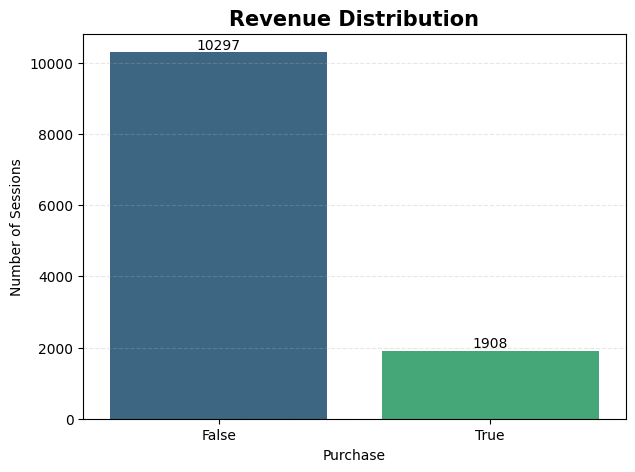

In [25]:
# ============================================
# توزيع المتغير المستهدف (Revenue)
# ============================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Revenue",
    hue="Revenue",
    palette="viridis",
    legend=False
)

# كتابة العدد فوق كل عمود
for container in ax.containers:
    ax.bar_label(container)

plt.title("Revenue Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Purchase")
plt.ylabel("Number of Sessions")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

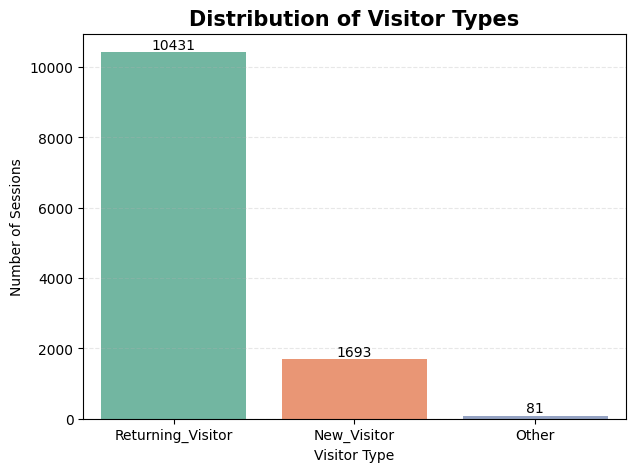

In [26]:
# ============================================
# توزيع أنواع الزوار
# ============================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="VisitorType",
    hue="VisitorType",
    palette="Set2",
    legend=False
)

# عرض عدد الجلسات فوق كل عمود
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Visitor Types", fontsize=15, fontweight="bold")
plt.xlabel("Visitor Type")
plt.ylabel("Number of Sessions")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/2597797574.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


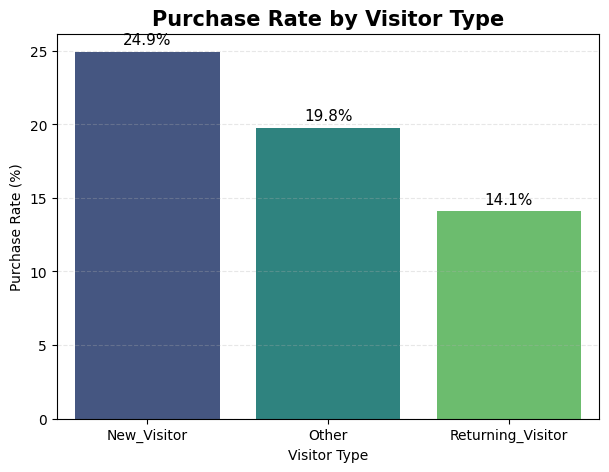

In [27]:
# ============================================
# نسبة الشراء حسب نوع الزائر
# ============================================

# حساب نسبة الشراء لكل نوع زائر
purchase_rate = (
    df.groupby("VisitorType")["Revenue"]
      .mean()
      .sort_values(ascending=False) * 100
)

# رسم النسبة المئوية
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=purchase_rate.index,
    y=purchase_rate.values,
    palette="viridis"
)

# كتابة النسبة فوق كل عمود
for i, value in enumerate(purchase_rate.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center", fontsize=11)

plt.title("Purchase Rate by Visitor Type", fontsize=15, fontweight="bold")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/1804573290.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


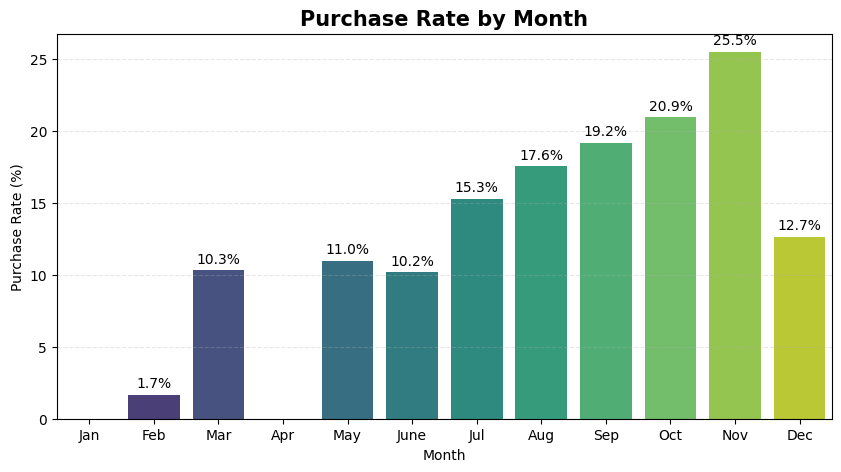

In [28]:
# ============================================
# نسبة الشراء حسب الشهر
# ============================================

# ترتيب الأشهر
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# حساب نسبة الشراء
purchase_rate_month = (
    df.groupby("Month")["Revenue"]
      .mean()
      .reindex(month_order)
      * 100
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=purchase_rate_month.index,
    y=purchase_rate_month.values,
    palette="viridis"
)

# كتابة النسبة فوق الأعمدة
for i, value in enumerate(purchase_rate_month.values):
    if not pd.isna(value):
        plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.title("Purchase Rate by Month", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/212300829.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


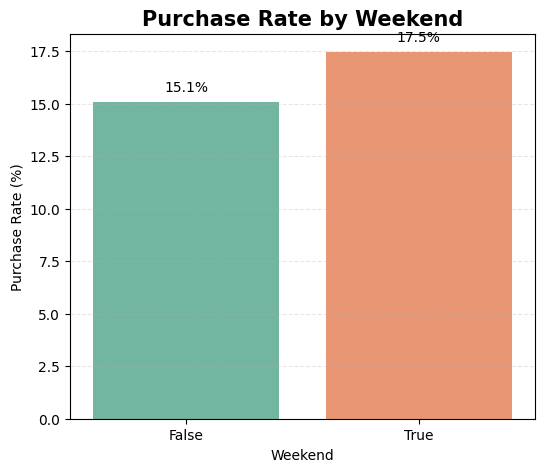

In [29]:
# ============================================
# نسبة الشراء حسب عطلة نهاية الأسبوع
# ============================================

purchase_rate_weekend = (
    df.groupby("Weekend")["Revenue"]
      .mean()
      * 100
)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=purchase_rate_weekend.index.astype(str),
    y=purchase_rate_weekend.values,
    palette="Set2"
)

for i, value in enumerate(purchase_rate_weekend.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.title("Purchase Rate by Weekend", fontsize=15, fontweight="bold")
plt.xlabel("Weekend")
plt.ylabel("Purchase Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [30]:
#لقسم الثاني: Numerical Analysis#

/tmp/ipykernel_916/3142262978.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


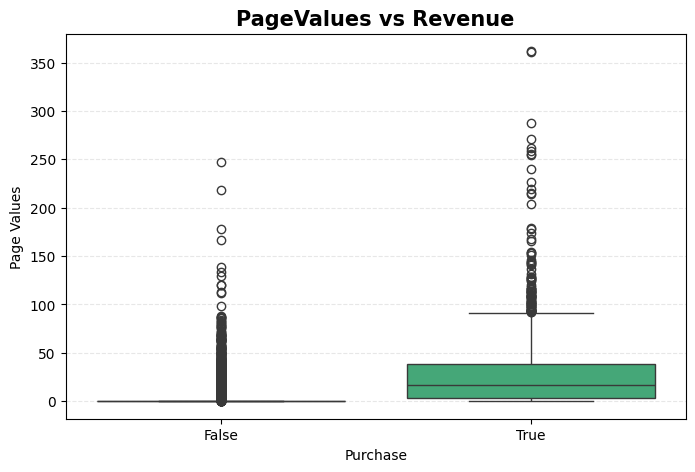

In [31]:
# ============================================
# PageValues vs Revenue
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="PageValues",
    palette="viridis"
)

plt.title("PageValues vs Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Purchase")
plt.ylabel("Page Values")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/1176460890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


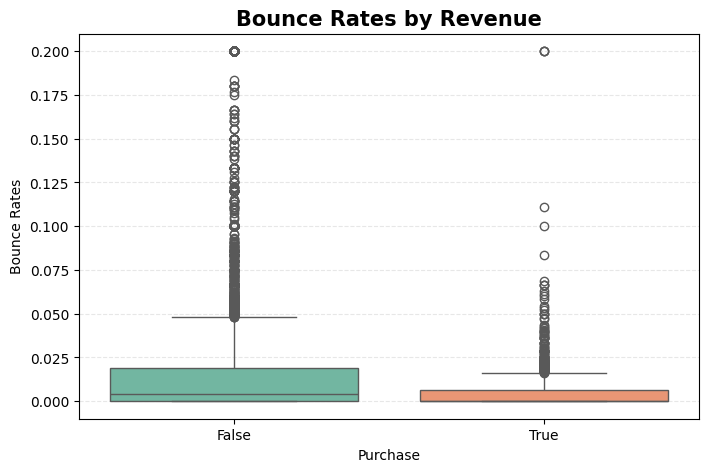

In [32]:
# ============================================
# Bounce Rates vs Revenue
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="BounceRates",
    palette="Set2"
)

plt.title("Bounce Rates by Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Purchase")
plt.ylabel("Bounce Rates")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/558199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


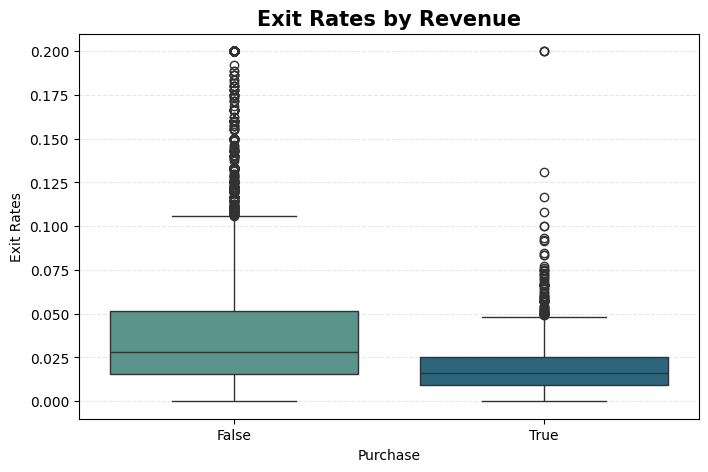

In [33]:
# ============================================
# Exit Rates vs Revenue
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ExitRates",
    palette="crest"
)

plt.title("Exit Rates by Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Purchase")
plt.ylabel("Exit Rates")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/2680836857.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


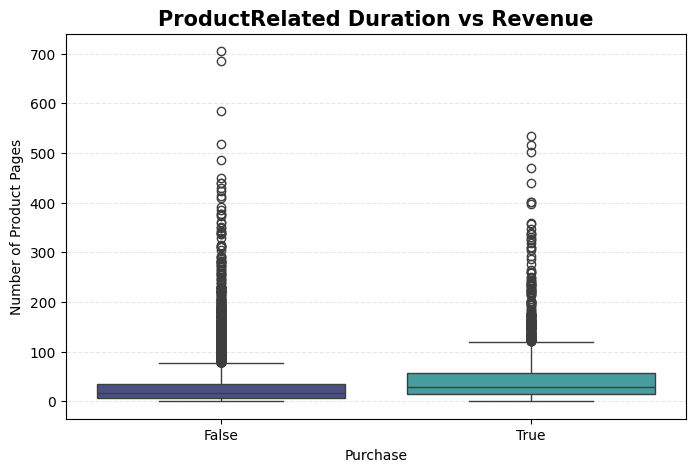

In [34]:
# ============================================
# Product Related Pages vs Revenue
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated",
    palette="mako"
)

plt.title("ProductRelated Duration vs Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Purchase")
plt.ylabel("Number of Product Pages")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

/tmp/ipykernel_916/1433688474.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


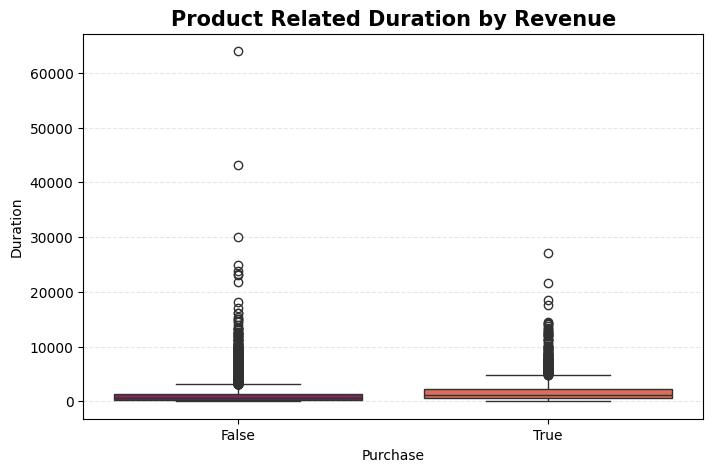

In [35]:

# ============================================
# Product Related Duration vs Revenue
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration",
    palette="rocket"
)

plt.title("Product Related Duration by Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Purchase")
plt.ylabel("Duration")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [36]:
# القسم الثالث: Correlation Analysis #

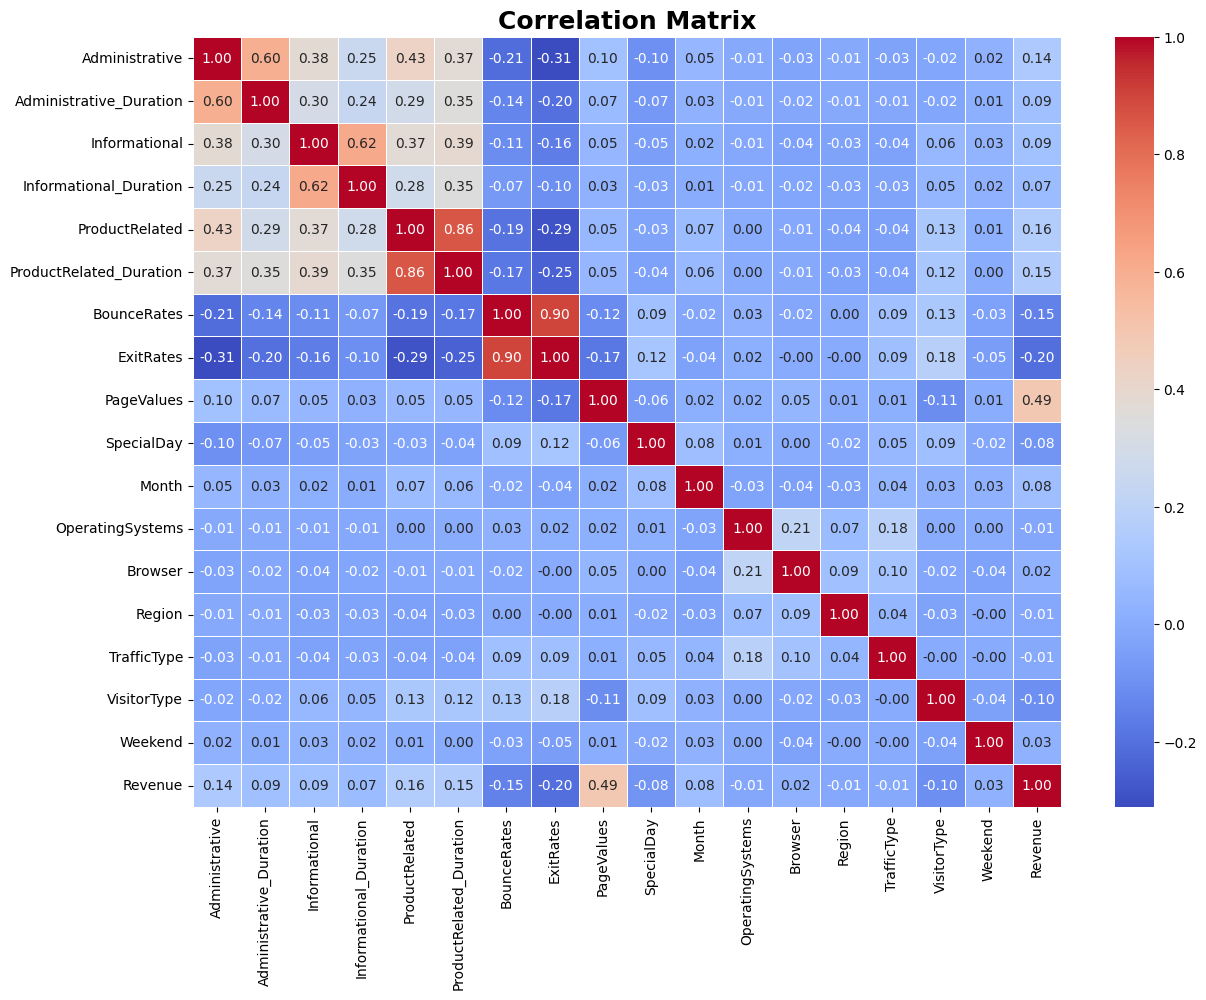

In [37]:
# ============================================
# Correlation Matrix (Heatmap)
# ============================================

# إنشاء نسخة من البيانات
corr_df = df.copy()

# تحويل المتغيرات النصية والمنطقية إلى أرقام
corr_df["Month"] = corr_df["Month"].astype("category").cat.codes
corr_df["VisitorType"] = corr_df["VisitorType"].astype("category").cat.codes
corr_df["Weekend"] = corr_df["Weekend"].astype(int)
corr_df["Revenue"] = corr_df["Revenue"].astype(int)

# حساب مصفوفة الارتباط
corr_matrix = corr_df.corr()

# رسم Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=18, fontweight="bold")

plt.show()

In [38]:
# Data Preprocessing #

In [39]:
#🟠 القسم الأول: Feature & Target Selection #

In [40]:
# ============================================
# Feature & Target Selection
# ============================================

# إنشاء نسخة من البيانات
model_df = df.copy()

# فصل المتغير الهدف عن بقية المتغيرات
X = model_df.drop("Revenue", axis=1)
y = model_df["Revenue"]

In [41]:
# عرض أبعاد Features
print("Features Shape:", X.shape)

# عرض أبعاد Target
print("Target Shape:", y.shape)

Features Shape: (12205, 17)
Target Shape: (12205,)


In [42]:
# Encoding (تحويل البيانات النصية إلى أرقام)#

In [43]:
# ============================================
# One-Hot Encoding
# ============================================

# تحويل الأعمدة النصية إلى أعمدة رقمية
X = pd.get_dummies(
    X,
    columns=["Month", "VisitorType"],
    drop_first=True
)

In [44]:
# عرض أول خمس صفوف بعد التحويل
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [45]:
# ============================================
# Train-Test Split
# ============================================

# استيراد دالة تقسيم البيانات
from sklearn.model_selection import train_test_split

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
# عرض حجم بيانات التدريب والاختبار
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (9764, 26)
X_test : (2441, 26)
y_train: (9764,)
y_test : (2441,)


In [47]:
# لمرحلة: Feature Scaling (StandardScaler)#

In [48]:
# ============================================
# Feature Scaling
# ============================================

# استيراد StandardScaler
from sklearn.preprocessing import StandardScaler

# إنشاء كائن من StandardScaler
scaler = StandardScaler()

# تطبيق Scaling على بيانات التدريب
X_train_scaled = scaler.fit_transform(X_train)

# تطبيق نفس التحويل على بيانات الاختبار
X_test_scaled = scaler.transform(X_test)

In [49]:
# المرحلة العاشرة: Logistic Regression #

In [50]:
# ============================================
# Logistic Regression
# ============================================

# استيراد نموذج Logistic Regression
from sklearn.linear_model import LogisticRegression

# استيراد مقاييس تقييم النموذج
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [51]:
# ============================================
# إنشاء نموذج Logistic Regression
# ============================================

# إنشاء النموذج
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [52]:
# ============================================
# تدريب نموذج Logistic Regression
# ============================================

# تدريب النموذج باستخدام بيانات التدريب
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [53]:
# 🟠 المرحلة: Prediction (التنبؤ) #

In [54]:
# ============================================
# Prediction
# ============================================

# استخدام النموذج للتنبؤ ببيانات الاختبار
y_pred = log_model.predict(X_test_scaled)

In [55]:
# عرض أول 10 توقعات
print(y_pred[:10])

[False False False False False False False False False False]


In [56]:
# عدد كل فئة في التوقعات
print(pd.Series(y_pred).value_counts())

False    2235
True      206
Name: count, dtype: int64


In [57]:
# 🟠 المرحلة: Model Evaluation #

In [58]:
# ============================================
# Model Evaluation
# ============================================

# حساب مقاييس الأداء
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# عرض النتائج
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.8894
Precision: 0.7718
Recall   : 0.4162
F1-Score : 0.5408


In [59]:
# المرحلة التالية: Confusion Matrix #

In [60]:
# ============================================
# Confusion Matrix - Logistic Regression
# ============================================

# إنشاء مصفوفة الأخطاء
cm = confusion_matrix(y_test, y_pred)

# عرض المصفوفة
print(cm)

[[2012   47]
 [ 223  159]]


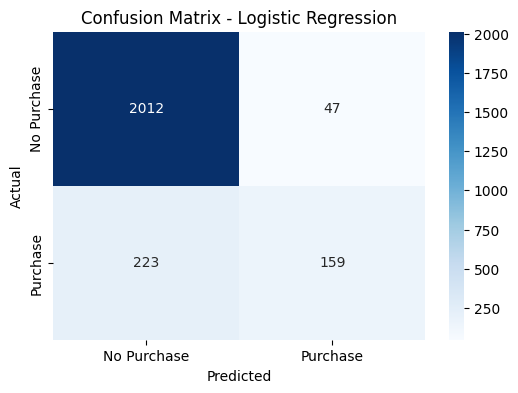

In [61]:
# رسم Confusion Matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [62]:
# المرحلة: Random Forest #

In [63]:
# ============================================
# Random Forest
# ============================================

# استيراد نموذج Random Forest
from sklearn.ensemble import RandomForestClassifier

In [64]:
# إنشاء نموذج Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [65]:
# تدريب نموذج Random Forest
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [66]:
# Random Forest — Prediction #

In [67]:
# ============================================
# Random Forest Prediction
# ============================================

# التنبؤ بنتائج بيانات الاختبار
y_pred_rf = rf_model.predict(X_test)

# عرض أول 10 توقعات
print(y_pred_rf[:10])

[False False False False False  True False False False False]


In [68]:
# Random Forest Evaluation #

In [69]:
# ============================================
# Random Forest Evaluation
# ============================================

# حساب مقاييس الأداء
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# عرض النتائج
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Accuracy : 0.9082
Precision: 0.7687
Recall   : 0.5916
F1-Score : 0.6686


In [70]:
# Random Forest — Confusion Matrix #

In [71]:
# ============================================
# Confusion Matrix - Random Forest
# ============================================

# إنشاء مصفوفة الأخطاء
cm_rf = confusion_matrix(y_test, y_pred_rf)

# عرض المصفوفة
print(cm_rf)

[[1991   68]
 [ 156  226]]


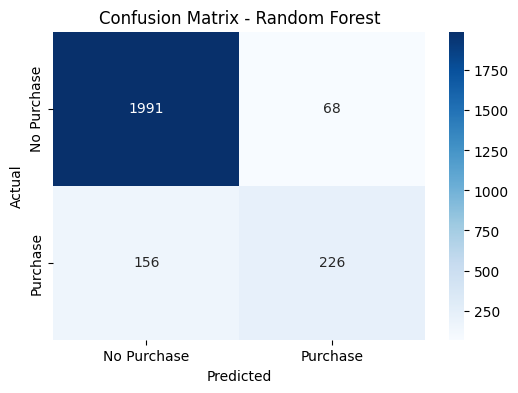

In [72]:
# رسم Confusion Matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [73]:
# المرحلة: Feature Importance #

In [74]:
# ============================================
# Feature Importance - Random Forest
# ============================================

# استخراج أهمية كل Feature
feature_importance = rf_model.feature_importances_

# إنشاء جدول يحتوي على أسماء المتغيرات وأهميتها
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

# ترتيب المتغيرات من الأكثر أهمية إلى الأقل
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# عرض الجدول
importance_df

,Feature,Importance
8,PageValues,0.364297
5,ProductRelated_Duration,0.091774
7,ExitRates,0.087852
4,ProductRelated,0.069622
1,Administrative_Duration,0.058308
6,BounceRates,0.057283
0,Administrative,0.041386
13,TrafficType,0.031643
12,Region,0.031095
3,Informational_Duration,0.027301


In [75]:
#توضيح اسماء المتغيرات #
feature_names = {
    "PageValues": "Page Value",
    "ProductRelated_Duration": "Time on Product Pages",
    "ExitRates": "Exit Rate",
    "ProductRelated": "Product Pages Viewed",
    "Administrative_Duration": "Time on Administrative Pages",
    "BounceRates": "Bounce Rate",
    "Administrative": "Administrative Pages Viewed",
    "TrafficType": "Traffic Source Type",
    "Region": "Region",
    "Informational_Duration": "Time on Informational Pages"
}

importance_df["Feature_Display"] = importance_df["Feature"].map(
    feature_names
).fillna(importance_df["Feature"])

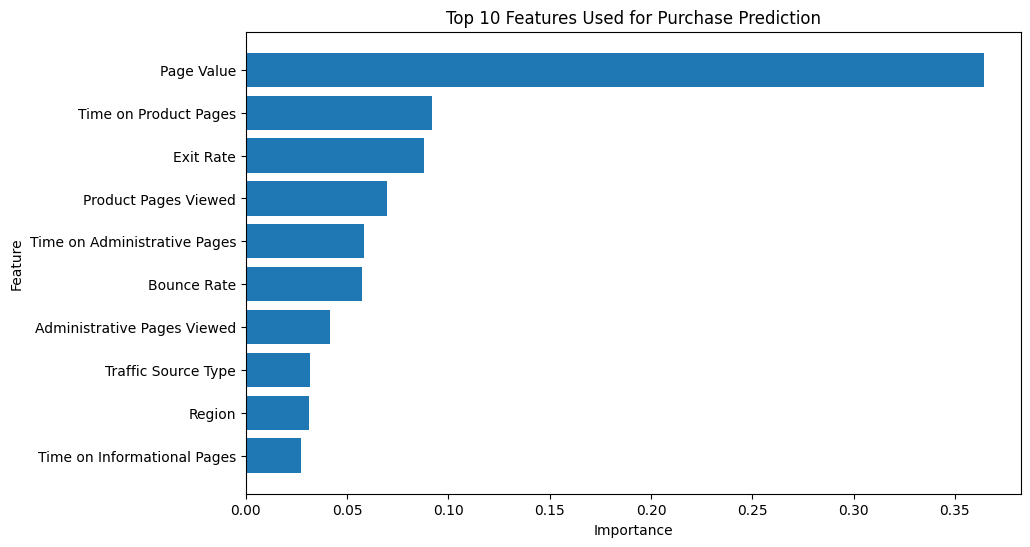

In [76]:
# رسم أهم المتغيرات

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature_Display"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Used for Purchase Prediction")

plt.show()

In [77]:
# Model Comparison #


In [78]:
# ============================================
# Model Comparison
# ============================================

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf
    ]
})

comparison_df

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.889390,0.908234
1,Precision,0.771845,0.768707
2,Recall,0.416230,0.591623
3,F1-Score,0.540816,0.668639
